In [ ]:
import pathlib

In [ ]:
# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import igraph as ig
import iplotx
import marimo as mo
import matplotlib.pyplot as plt
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-09-26T22:02:03.721645+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1064-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

marimo    : 0.23.2
matplotlib: 3.10.7
teeplot   : 1.4.2
igraph    : 0.11.9
iplotx    : 1.7.1

```

## Model

Render the "complete adjacency graph" (CAG) mutation tree: the same
diagram convention already used for the 3-site model in
`2026-06-24-community-assembly-graph.py` (pair-of-circulating-strains
nodes, `+gained`/`-lost` strain edge labels, a highlighted node for
the wildtype/full-complement pair), generalized here to 4 sites and
laid out programmatically instead of by hand.

A node is an unordered pair of `N_SITES`-bit strains `{A, B}`
currently co-circulating, starting from the singleton wildtype
(all-zero) strain.
Each edge mutates one bit position in one of the two strains,
replacing it in the pair (labeled `+<new strain>` / `-<old strain>`,
or just `+<new strain>` for the first edge out of the singleton
root).
Bit positions are resolved one per tree level, last position first:
the first edge fixes which bit distinguishes the founding pair, and
each subsequent level's branch chooses which of the two current
strains receives the next bit.
This reaches every complementary strain pair (`A`, bitwise-NOT `A`)
exactly once, as a leaf: `2**(N_SITES - 1)` of them in total.
The leaf pairing the original wildtype with its full complement is
highlighted.

In [ ]:
def build_cag_tree(n_sites):
    # Resolve bit positions from last to first: the first edge out
    # of the root always introduces the last bit, then each level
    # resolves the next-lowest position by choosing which of the
    # pair's two strains receives it.
    order = list(range(n_sites - 1, -1, -1))
    root = "root"
    states = [root]
    state_index = {root: 0}
    edges = []

    frontier = [root]
    for pos in order:
        next_frontier = []
        for state in frontier:
            if state == root:
                children = [(frozenset(), frozenset({pos}))]
            else:
                slot_a, slot_b = state
                children = [
                    (slot_a | {pos}, slot_b),
                    (slot_a, slot_b | {pos}),
                ]
            for child in children:
                if child not in state_index:
                    state_index[child] = len(states)
                    states.append(child)
                edges.append((state_index[state], state_index[child]))
                next_frontier.append(child)
        frontier = next_frontier

    def bits_to_str(bits):
        return "".join("1" if i in bits else "0" for i in range(n_sites))

    def state_label(state):
        if state == root:
            return bits_to_str(frozenset())
        slot_a, slot_b = state
        return f"{bits_to_str(slot_a)}\n{bits_to_str(slot_b)}"

    graph = ig.Graph(directed=True)
    graph.add_vertices(len(states))
    graph.add_edges(edges)
    graph.vs["label"] = [state_label(s) for s in states]

    full_complement = (frozenset(), frozenset(range(n_sites)))
    graph.vs["special"] = [s == full_complement for s in states]

    edge_labels = []
    for parent_idx, child_idx in edges:
        parent, child = states[parent_idx], states[child_idx]
        if parent == root:
            edge_labels.append(f"+{bits_to_str(child[1])}")
        elif child[0] != parent[0]:
            edge_labels.append(
                f"+{bits_to_str(child[0])}\n-{bits_to_str(parent[0])}"
            )
        else:
            edge_labels.append(
                f"+{bits_to_str(child[1])}\n-{bits_to_str(parent[1])}"
            )
    graph.es["label"] = edge_labels
    return graph

In [ ]:
N_SITES = 4
cag_graph = build_cag_tree(N_SITES)
print(f"CAG tree: {cag_graph.vcount()} nodes, {cag_graph.ecount()} edges")

CAG tree: 16 nodes, 15 edges


## Render

Layout is computed with igraph's Reingold-Tilford tree-drawing
algorithm (`layout_reingold_tilford`), then drawn with `iplotx`
(matplotlib backend).
The root's position is nudged slightly off-center so its one
outgoing edge isn't perfectly vertical, which otherwise flips that
edge label upside down.

teeplots/2026-09-26-cagrender/a=cag-mutation-tree+viz=subplots+ext=.pdf
teeplots/2026-09-26-cagrender/a=cag-mutation-tree+viz=subplots+ext=.png


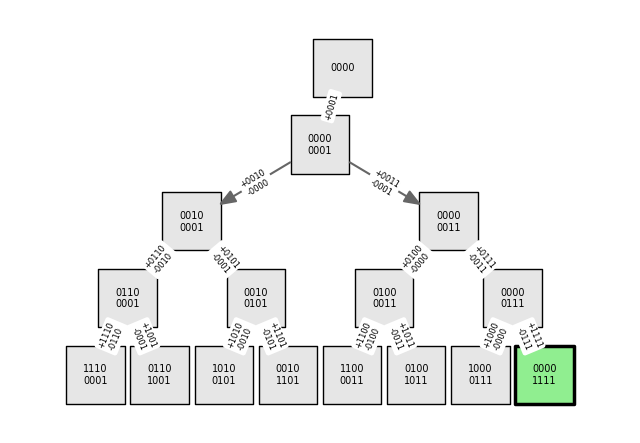

In [ ]:
_layout = cag_graph.layout_reingold_tilford(root=[0])
_root_x, _root_y = _layout[0]
_layout[0] = (_root_x + 0.35, _root_y)

_vertex_facecolor = [
    "#90ee90" if special else "0.9" for special in cag_graph.vs["special"]
]
_vertex_linewidth = [
    2.5 if special else 1.0 for special in cag_graph.vs["special"]
]

with tp.teed(
    plt.subplots,
    figsize=(8, 5.5),
    teeplot_outattrs={"a": "cag-mutation-tree"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as (fig, ax):
    iplotx.network(
        cag_graph,
        layout=_layout,
        vertex_labels=cag_graph.vs["label"],
        edge_labels=cag_graph.es["label"],
        ax=ax,
        vertex_facecolor=_vertex_facecolor,
        vertex_edgecolor="black",
        vertex_linewidth=_vertex_linewidth,
        vertex_marker="r",
        vertex_size=42,
        vertex_label_color="black",
        vertex_label_size=7,
        edge_label_size=6,
        edge_color="0.4",
        show=False,
    )
    ax.margins(0.1)
    ax.invert_yaxis()